In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

In [2]:
df, top_k, source = load_data(f"results/mcl1_mmgbsa_tradeoff.sqlite", k_ratio=0.01)
K = len(top_k)

In [74]:
K

595

In [5]:
df["Molecules screened"] = df["Iteration"] * df["batch_size"]

In [6]:
HUE_ORDER=sorted(df["init_sampler"].unique())
HUE_ORDER

['closest', 'random']

In [68]:

stats = df.groupby(["Embedding Model", "init_sampler", "batch_size", "n_iter", "experiment_id"])["is_top_k"].sum().reset_index()

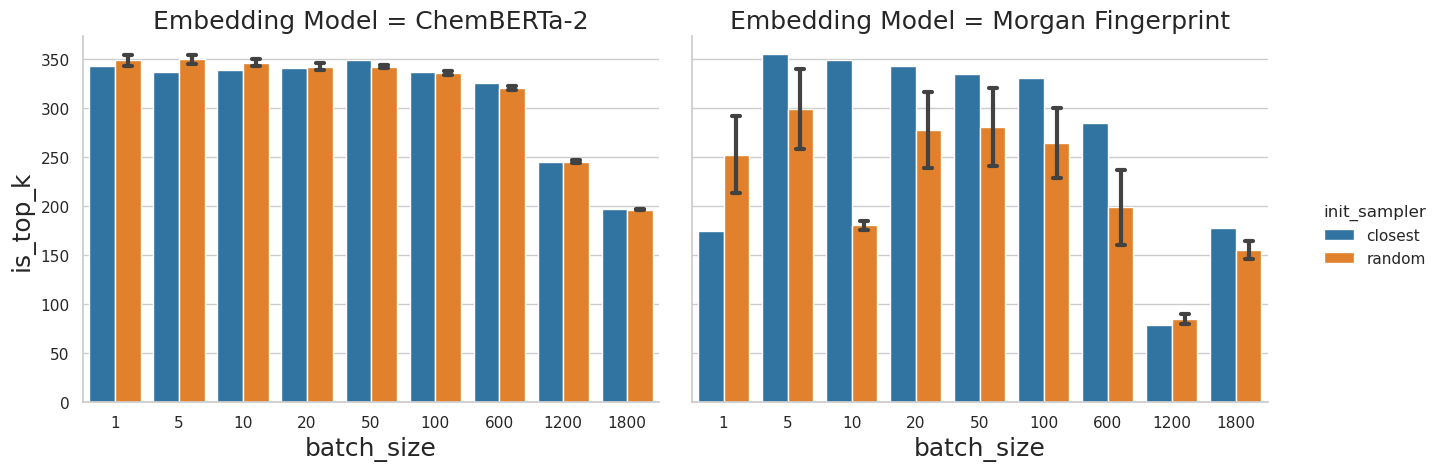

In [92]:
from scipy.stats import sem

g = sns.catplot(
    stats,  # Average over different runs
    y="is_top_k",
    x="batch_size",
    col="Embedding Model",
    hue="init_sampler",
    kind="bar",
    estimator= lambda x: x.mean(),
    errorbar="se",
    capsize=0.25
)

g.figure.set_size_inches(15, 5)

In [152]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

def plot_progress(data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharex=True, sharey=True)
    ax1.set_facecolor('white')
    ax2.set_facecolor('white')
    fig.set_facecolor('white')

    for ax, (gvar, d) in zip([ax1, ax2], data.groupby("Embedding Model")):

        ax.set_title(gvar)

        batch_sizes = sorted(d['batch_size'].unique())
        n_colors = len(batch_sizes)
        norm = Normalize(vmin=min(batch_sizes), vmax=max(batch_sizes))
        colors = plt.cm.viridis(np.linspace(0, 1, n_colors))

        for color, (bs, group) in zip(colors, d.groupby(["batch_size"])):
            bs = bs[0]

            per_run = group.groupby(["experiment_id", "Molecules screened"])["is_top_k_cum"].max()
            retrieval = per_run.groupby(["Molecules screened"]).agg(["mean", "sem"]) / K


            if bs >= 600:
                # retrieval["mean"].plot(ax=ax, color=color, label=bs, marker="o", markeredgecolor="k", yerr=retrieval["sem"])
                ax.errorbar(retrieval.index, retrieval["mean"], retrieval["sem"], color=color, label=bs, marker="o", markeredgecolor="k", capsize=5)

            else:
                retrieval["mean"].plot(ax=ax, color=color, label=bs)
                ax.fill_between(
                    retrieval.index, retrieval["mean"] - retrieval["sem"], retrieval["mean"] + retrieval["sem"], color=color, alpha=0.2
                )

    ax1.set_ylabel("Percentage top-1% found")
    leg = ax2.legend(title='Batch size', 
                            loc='center left',
                            bbox_to_anchor=(1.02, 0.5),
                            frameon=True,
                            edgecolor='none',
                            title_fontsize=10)
    leg.get_frame().set_facecolor('white')

    return fig

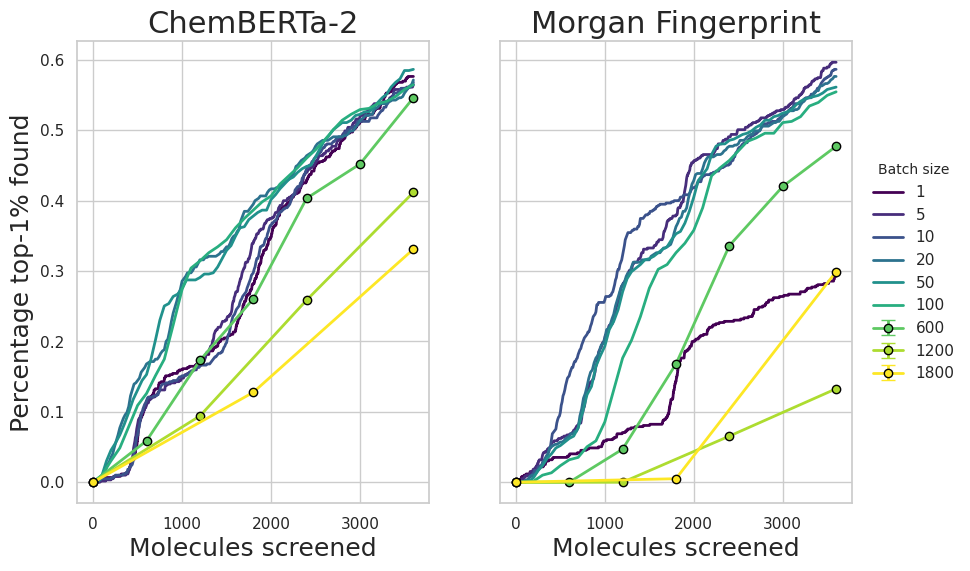

In [153]:
_ = plot_progress(df[df["init_sampler"] == "closest"])

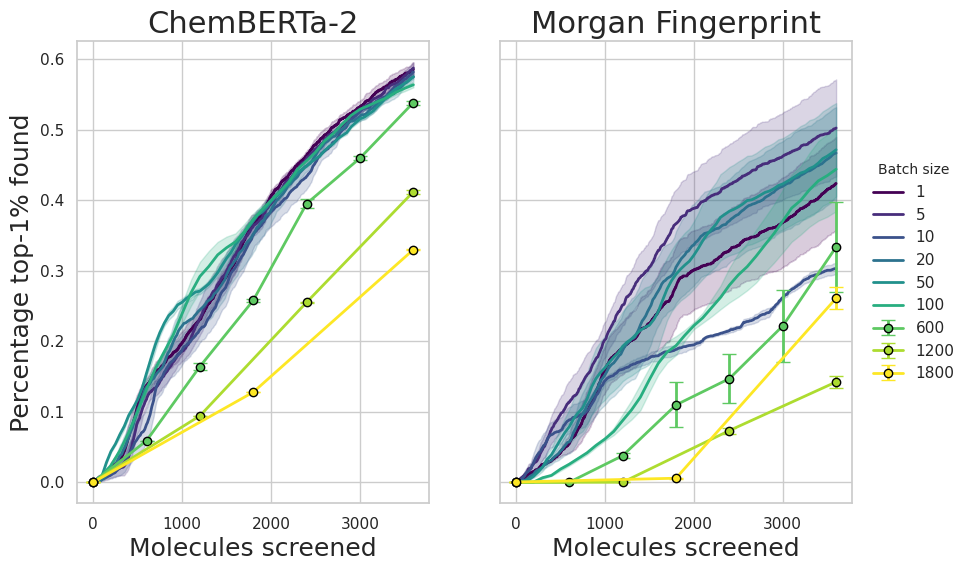

In [154]:
_ = plot_progress(df[df["init_sampler"] == "random"])